## **Problème** : 
L’organisation ne sait pas si la répartition du travail entre centres et projet est équilibrée.

## *Hypothese* :

-	H1 : certains centres sont plus chargés que d’autres
-	H2 : certaines phase consomme plus de ressources
-	H3 : des projets consomme beaucoup en charge total par rapport a d’autres
-	H4 : des poste sont déséquilibrer (d’autres travail plus par rapport a d’autres)


## 1. Audit des données

Dans cette partie, on vérifie la structure du fichier :

- nombre de lignes et de colonnes,
- type des variables (texte / nombre),
- valeurs manquantes,
- doublons éventuels.

Cela permet de voir si le fichier est exploitable tel quel ou s’il faut le nettoyer.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
df = pd.read_excel(r"C:\Users\Tenordem\Documents\projet-repartition-charge\data\raw\data_complet_v2.xlsx")

In [4]:
df.head()

,NOM_SI,ModuleId,PhaseId,Types_phases,utilisateur_id2,Centre,DateDebutPrev,DateDebutReelle,DateFinPrevisionnelle,DateFinReelle,DateFinActualisée,charge_previsionnelle_n,ChargeTotaleEstimee,ChargeTotaleActualisee,ModuleChargeInitiale,ChargeGarantie
0,SI_HORS-PROCESSUS,5477,10407,AUTRES,-,-,2024-01-01 00:00:00,2024-01-01 00:00:00,2050-12-31 00:00:00,2050-12-31 00:00:00,-,0,2300,2300,0,-
1,SI_HORS-PROCESSUS,5478,10408,AUTRES,-,-,2024-01-01 00:00:00,2024-01-01 00:00:00,2050-12-31 00:00:00,2050-12-31 00:00:00,-,0,2300,2300,0,-
2,SI_HORS-PROCESSUS,5479,10409,AUTRES,-,-,2024-01-01 00:00:00,2024-01-01 00:00:00,2050-12-31 00:00:00,2050-12-31 00:00:00,-,0,2300,2300,0,-
3,SI_HORS-PROCESSUS,5476,10406,AUTRES,-,-,2024-01-01 00:00:00,2024-01-01 00:00:00,2050-12-31 00:00:00,2050-12-31 00:00:00,-,2300,2300,2300,0,-
4,INITIATIVE PODEV 2024,5535,10542,REALISATION,305,CDAD-BDX,2024-01-01 00:00:00,2024-01-01 00:00:00,2050-12-31 00:00:00,2024-09-30 00:00:00,-,0,2200,2200,2200,-


In [5]:
df.shape


(7915, 16)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7915 entries, 0 to 7914
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   NOM_SI                   7915 non-null   object
 1   ModuleId                 7915 non-null   object
 2   PhaseId                  7915 non-null   object
 3   Types_phases             7915 non-null   object
 4   utilisateur_id2          7915 non-null   object
 5   Centre                   7914 non-null   object
 6   DateDebutPrev            7915 non-null   object
 7   DateDebutReelle          7915 non-null   object
 8   DateFinPrevisionnelle    7915 non-null   object
 9   DateFinReelle            7915 non-null   object
 10  DateFinActualisée        7915 non-null   object
 11  charge_previsionnelle_n  7915 non-null   object
 12  ChargeTotaleEstimee      7915 non-null   object
 13  ChargeTotaleActualisee   7915 non-null   object
 14  ModuleChargeInitiale     7915 non-null  

In [7]:
df.isna().sum().sort_values(ascending=False)


Centre                     1
NOM_SI                     0
PhaseId                    0
ModuleId                   0
Types_phases               0
utilisateur_id2            0
DateDebutPrev              0
DateDebutReelle            0
DateFinPrevisionnelle      0
DateFinReelle              0
DateFinActualisée          0
charge_previsionnelle_n    0
ChargeTotaleEstimee        0
ChargeTotaleActualisee     0
ModuleChargeInitiale       0
ChargeGarantie             0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:

df[["ChargeTotaleEstimee", "ChargeTotaleActualisee"]].describe()


,ChargeTotaleEstimee,ChargeTotaleActualisee
count,7915,7915
unique,119,183
top,0,0
freq,4580,4578


## Résumé de l’audit des données

- Le dataset contient **7915 lignes** et **16 colonnes**.
- Les colonnes principales (Centre, NOM_SI, Types_phases, utilisateur_id2,
  ChargeTotaleEstimee, ChargeTotaleActualisee,moduleid) sont bien présentes.
- Les colonnes de charge sont bien de type numérique.
- On observe 1 valeurs manquantes sur certaines colonnes CENTRE.
- Le nombre de doublons est nul.
- Les charges varient globalement a 4580 heures.

Conclusion : les données sont suffisamment propres pour commencer l’analyse
des centres, des phases, des projets et des postes.


# 2. Analyse univariée

Dans cette partie, on regarde chaque variable importante séparément :

- Centres
- Phases
- Projets (NOM_SI)
- Module
- Postes
- Charges (estimée et réelle)

Cela permet de voir quels centres, quelles phases ou quels projets sont les plus présents
dans le fichier et de commencer à relier avec nos hypothèses H1 à H4.

### 2.1. Répartition des lignes par centre


In [12]:
centre_counts = df["Centre"].value_counts()
centre_counts.head


<bound method NDFrame.head of Centre
CDAD-BDX       1994
CDAD-T         1821
CDAD-R         1476
CDAD-Bo        1310
-              1037
PODEV-EM        239
DEMO1            35
FABNUM            1
SOPRASTERIA       1
Name: count, dtype: int64>

In [14]:
centre_counts_pct = df["Centre"].value_counts(normalize=True) * 100
centre_counts_pct.head


<bound method NDFrame.head of Centre
CDAD-BDX       25.195855
CDAD-T         23.009856
CDAD-R         18.650493
CDAD-Bo        16.552944
-              13.103361
PODEV-EM        3.019965
DEMO1           0.442254
FABNUM          0.012636
SOPRASTERIA     0.012636
Name: proportion, dtype: float64>

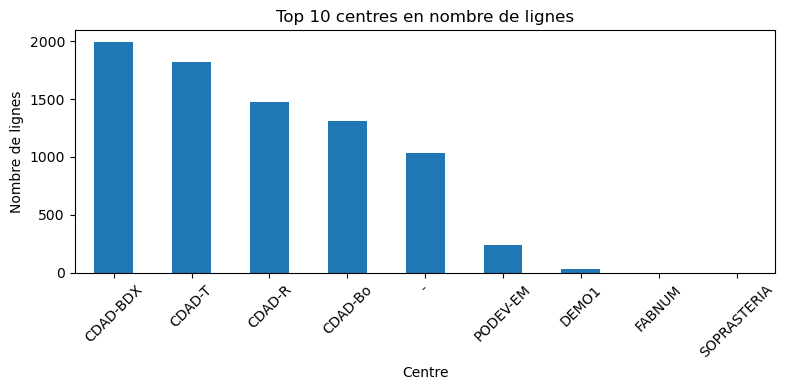

In [18]:
plt.figure(figsize=(8,4))
centre_counts.head(10).plot(kind="bar")
plt.title("Top 10 centres en nombre de lignes")
plt.ylabel("Nombre de lignes")
plt.xlabel("Centre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Commentaire :**

Les centres les plus présents dans le fichier sont par exemple : CDAD-BDX et CDAD-T.
On voit qu'ils apparaissent beaucoup plus souvent que les autres.

Cela va dans le sens de l’hypothèse H1 : certains centres jouent un rôle plus important
en globale.


### 2.2. Répartition des lignes par type de phase


In [19]:
phase_counts = df["Types_phases"].value_counts()
phase_counts

Types_phases
AUTRES         4003
REALISATION    1856
MAINTENANCE    1533
ETUDE           502
-                21
Name: count, dtype: int64

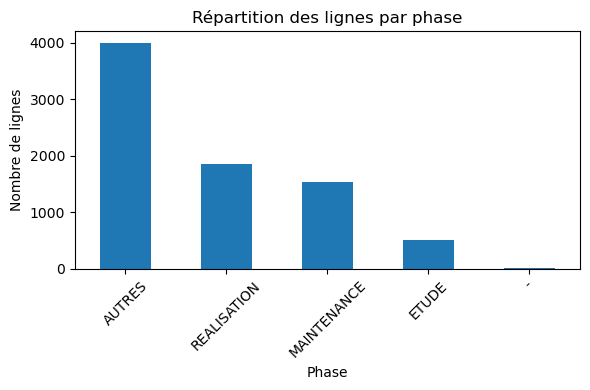

In [20]:
plt.figure(figsize=(6,4))
phase_counts.plot(kind="bar")
plt.title("Répartition des lignes par phase")
plt.ylabel("Nombre de lignes")
plt.xlabel("Phase")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Commentaire :**

On observe que la phase la plus fréquente est AUTRES.
Cela signifie qu’une grande partie de l’activité se situe sur cette phase.

Cela soutient l’idée de l’hypothèse H2 : certaines phases sont plus dominantes que d’autres.


### 2.3. Nombre de lignes par projet (NOM_SI)


In [23]:
module_counts = df["NOM_SI"].value_counts()
module_counts.head(10)


NOM_SI
HORS-PROC                      301
MAN-SOUT                       259
Autres_Activites_Militaires    239
SOUTIEN-T                      220
VIE_COURANTE4                  178
DROITS_BDX                     171
ACTIVITES_TRANSVERSES-Bo       170
FORMATION_INFORMATION2         149
CONGES_EXCEPTIONNELS_T         147
MOBILIA                        125
Name: count, dtype: int64

In [24]:
df["NOM_SI"].nunique()


378

**Commentaire :**

Le fichier contient 378 projets différents.
Les projets les plus présents dans les données sont par exemple :
- HORS-PROC
- MAN-SOUT
- Autres_Activites_Militaires 

Cela donne une première vision des projets importants.
Plus tard, on regardera la charge totale par projet pour vraiment tester H3.


### 2.4. Nombre de postes distincts


In [25]:
nb_postes = df["utilisateur_id2"].nunique()
nb_postes


436

In [26]:
poste_counts = df["utilisateur_id2"].value_counts()
poste_counts.head(10)


utilisateur_id2
-      1029
155      95
122      75
457      70
168      70
415      68
314      63
258      63
313      59
202      56
Name: count, dtype: int64

**Commentaire :**

Il y a **436 postes distincts** dans le fichier.
Certains postes apparaissent beaucoup plus souvent que les autres,
ce qui peut être un signal de déséquilibre de charge (H4).
On le vérifiera ensuite en regardant la charge par poste.


### 2.5. Distribution des charges estimées et réelles


In [27]:
df[["ChargeTotaleEstimee", "ChargeTotaleActualisee"]].describe()


,ChargeTotaleEstimee,ChargeTotaleActualisee
count,7915,7915
unique,119,183
top,0,0
freq,4580,4578


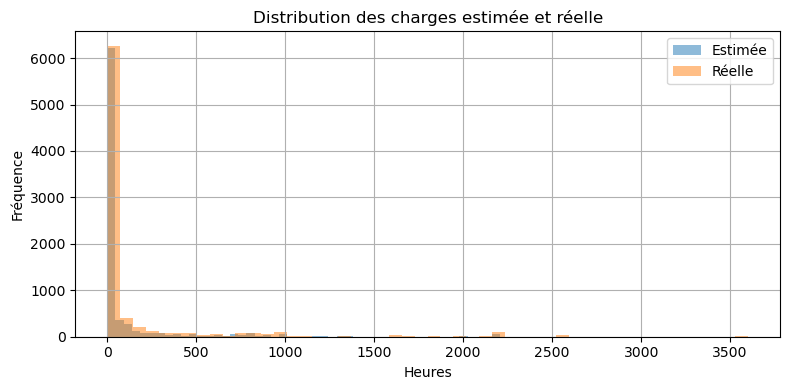

In [38]:
plt.figure(figsize=(8,4))
df["ChargeTotaleEstimee"].hist(bins=50, alpha=0.5, label="Estimée")
df["ChargeTotaleActualisee"].hist(bins=50, alpha=0.5, label="Réelle")
plt.legend()
plt.title("Distribution des charges estimée et réelle")
plt.xlabel("Heures")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()


**Commentaire :**

Les charges estimées et réelles montrent que :

- la médiane de la charge estimée est d’environ 4580 heures,
- la médiane de la charge réelle est d’environ 4578 heures,
- La majorité des charges est très faible (vers 0–50h),
et quelques valeurs très fortes (jusqu’à 3000+) tirent la droite vers la droite.

C’est typique des données de charge de projet → longue traîne.

Cela confirme qu’il y a probablement des centres ou des projets beaucoup plus sollicités
que d’autres, ce qui rejoint nos hypothèses.


## 3. Analyse bivariée
Dans cette partie, nous analysons la charge réelle et/ou estimée en fonction des :
- centres (H1)
- phases (H2)
- projets / modules (H3)
- postes (H4)

Cela permet de vérifier nos hypothèses de départ et d’observer les déséquilibres éventuels.


### 3.1 Charge totale réelle par centre (H1)


In [41]:
charge_par_centre = (
    df.groupby("Centre", as_index=False)
      .agg(ChargeReelle=("ChargeTotaleActualisee", "sum"))
      .sort_values("ChargeReelle", ascending=False)
)

charge_par_centre.head(10)


,Centre,ChargeReelle
4,CDAD-T,375826.000000
2,CDAD-Bo,277537.357422
1,CDAD-BDX,226556.149780
3,CDAD-R,190495.989990
0,-,35283.000000
7,PODEV-EM,13039.000000
5,DEMO1,2806.000000
6,FABNUM,0.000000
8,SOPRASTERIA,0.000000


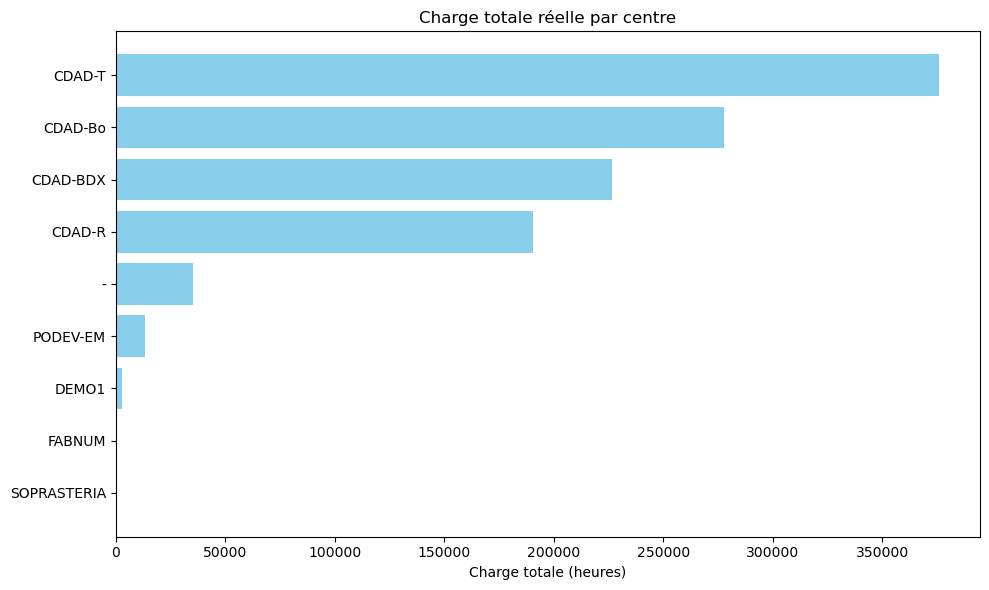

In [42]:
plt.figure(figsize=(10,6))
plt.barh(charge_par_centre["Centre"], charge_par_centre["ChargeReelle"], color="skyblue")
plt.gca().invert_yaxis()
plt.title("Charge totale réelle par centre")
plt.xlabel("Charge totale (heures)")
plt.tight_layout()
plt.show()


**Commentaire :**  
Les centres les plus chargés sont :
- centre 1 : CDAD-T
- centre 2 : CDAD-BO
- centre 3 : CDAD-R

Cela confirme que la charge n’est pas répartie équitablement (H1).


### 3.2 Charge totale réelle par phase (H2)


In [43]:
charge_par_phase = (
    df.groupby("Types_phases", as_index=False)
      .agg(ChargeReelle=("ChargeTotaleActualisee", "sum"))
      .sort_values("ChargeReelle", ascending=False)
)

charge_par_phase


,Types_phases,ChargeReelle
4,REALISATION,1.058609e+06
3,MAINTENANCE,3.625450e+04
2,ETUDE,1.574900e+04
1,AUTRES,1.093100e+04
0,-,0.000000e+00


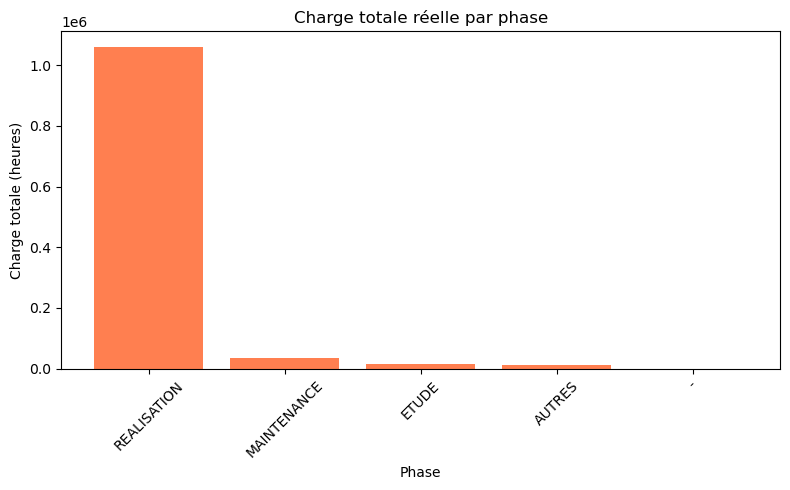

In [44]:
plt.figure(figsize=(8,5))
plt.bar(charge_par_phase["Types_phases"], charge_par_phase["ChargeReelle"], color="coral")
plt.title("Charge totale réelle par phase")
plt.ylabel("Charge totale (heures)")
plt.xlabel("Phase")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Commentaire :**  
La phase la plus consommatrice est : REALISATION  
Puis viennent les phases : MAINTENANCE, ETUDE.

Cela confirme l’hypothèse H2 : certaines phases mobilisent beaucoup plus de charge.


### 5.3 Charge totale réelle par projet / module (H3)


In [45]:
charge_par_module = (
    df.groupby("NOM_SI", as_index=False)
      .agg(ChargeReelle=("ChargeTotaleActualisee", "sum"))
      .sort_values("ChargeReelle", ascending=False)
)

charge_par_module.head(10)


,NOM_SI,ChargeReelle
170,INITIATIVE PODEV 2024,154182.000000
141,GEOSTAR_NG,75065.719727
140,GEMAPAL,71179.397461
41,APPUI_PROJETS,50500.000000
327,SISTEX_V3,39610.000000
86,CRISTAL-NG,37920.000000
252,PERSEE,37169.000000
143,GESCANA,33916.000000
331,SI_JDM,33786.000000
209,MOBILIA,33547.000000


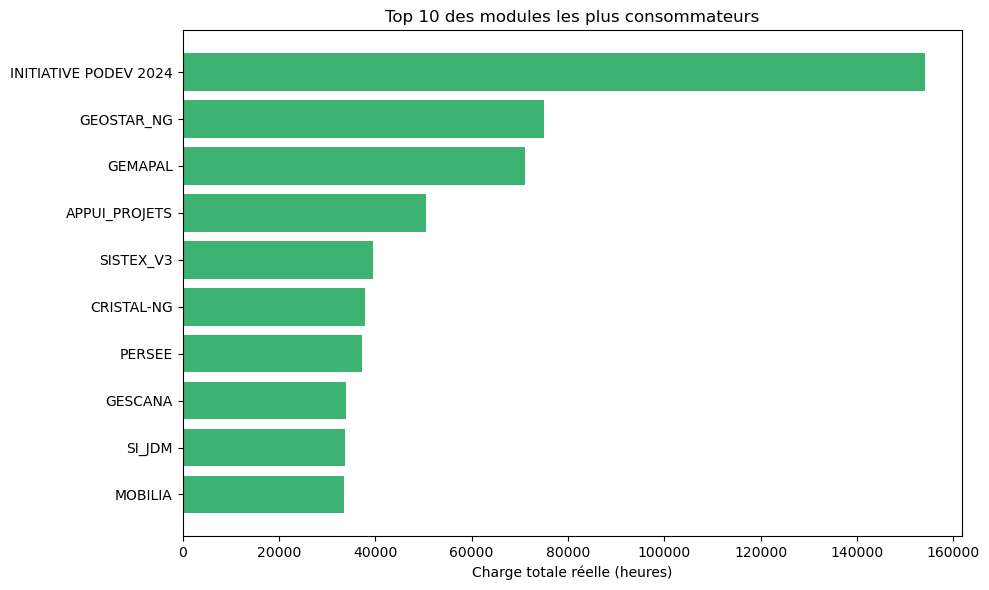

In [46]:
plt.figure(figsize=(10,6))
plt.barh(charge_par_module["NOM_SI"].head(10), charge_par_module["ChargeReelle"].head(10), color="mediumseagreen")
plt.gca().invert_yaxis()
plt.title("Top 10 des modules les plus consommateurs")
plt.xlabel("Charge totale réelle (heures)")
plt.tight_layout()
plt.show()


**Commentaire :**  
Les modules les plus consommateurs sont :
1. INITIATIVE PODEV 2024
2. GEOSTAR_NG
3. GEMAPAL

Cela confirme l’hypothèse H3 : une grande partie de la charge se concentre sur quelques modules prioritaires.


### 3.4 Charge totale réelle par poste (H4)


In [47]:
charge_par_poste = (
    df.groupby("utilisateur_id2", as_index=False)
      .agg(ChargeReelle=("ChargeTotaleActualisee", "sum"))
      .sort_values("ChargeReelle", ascending=False)
)

charge_par_poste.head(10)


,utilisateur_id2,ChargeReelle
0,-,35123.000000
220,415,18020.000000
235,430,17472.000000
237,432,16250.000000
358,598,15516.000000
241,436,14503.000000
129,255,14294.639893
76,202,13941.639893
130,256,13159.139893
140,268,12059.639893


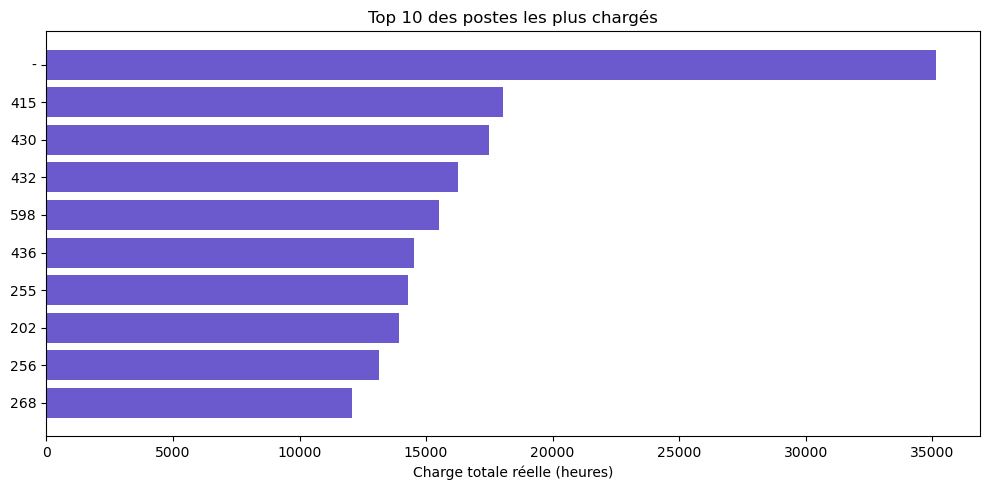

In [48]:
plt.figure(figsize=(10,5))
plt.barh(charge_par_poste["utilisateur_id2"].head(10), charge_par_poste["ChargeReelle"].head(10), color="slateblue")
plt.gca().invert_yaxis()
plt.title("Top 10 des postes les plus chargés")
plt.xlabel("Charge totale réelle (heures)")
plt.tight_layout()
plt.show()


**Commentaire :**

Les postes les plus chargés sont :
1. Poste "-" (35 123 h)
2. Poste 415 (18 020 h)
3. Poste 430 (17 472 h)

On remarque qu’un poste mal renseigné (“-”) concentre énormément de charge.
Cela confirme l’hypothèse H4 : certains postes portent une charge beaucoup plus élevée
que la majorité, ce qui peut indiquer une répartition inégale du travail
ou un problème de saisie à analyser plus tard.


## 8. Conclusion de l’EDA

L’analyse exploratoire confirme les quatre hypothèses de départ :

- **H1 – Centres** : certains centres (CDAD-T, CDAD-Bo, CDAD-R) concentrent la majorité
  de la charge totale. La répartition est clairement inégale.
  
- **H2 – Phases** : la phase RÉALISATION est de loin la plus consommatrice,
  suivie par MAINTENANCE et ÉTUDE. Certaines phases demandent donc plus de ressources.

- **H3 – Modules** : quelques projets dominent largement la charge réelle,
  notamment INITIATIVE PODEV 2024, GEOSTAR_NG et GEMAPAL.
  La charge n'est pas uniformément répartie entre les projets.

- **H4 – Postes** : certains postes portent une charge très élevée,
  bien supérieure à celle des autres, ce qui peut indiquer des situations
  de surcharge ou un besoin de rééquilibrage.

**Conclusion générale :**
L'EDA montre des déséquilibres importants dans la répartition de la charge
entre centres, phases, projets et postes.  
La prochaine étape sera de construire les indicateurs et agrégations nécessaires
pour le tableau de bord, afin d’aider le responsable à piloter ces écarts.
